In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import IPython.display as ipd

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
print('All imports successful!')

All imports successful!


---
## Step 1: Generate 

We will simulate a voice signal as a sum of sinusoids across a range of frequencies (including low frequencies we want to *preserve*), plus a DC offset we want to *remove*.



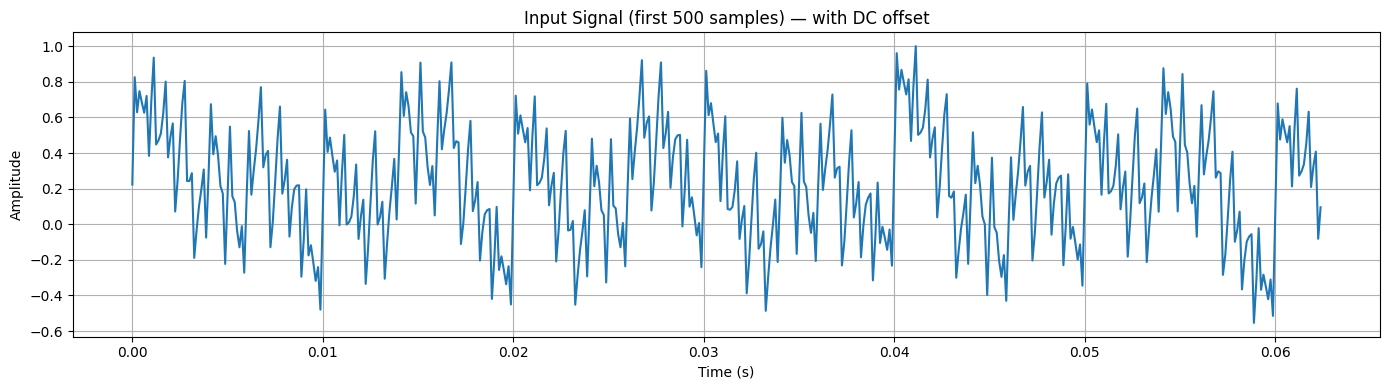

Sampling rate  : 8000 Hz
Signal length  : 16000 samples  (2.0 s)
Mean (DC level): 0.2230


In [14]:
# ---- Sampling parameters ----
fs = 8000          # Sampling frequency in Hz (typical for voice)
duration = 2.0     # seconds
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# ---- Synthetic voice-like signal ----
# Voice has energy from ~80 Hz (fundamental) up to ~3400 Hz
# We include some low frequencies (80-300 Hz) that we do NOT want to remove
freqs = [80, 150, 200, 300, 500, 800, 1200, 2000, 3000]
x = sum(np.sin(2 * np.pi * f * t) for f in freqs)

# ---- Add a DC offset (the thing we want to remove) ----
dc_offset = 1.5
x = x + dc_offset

# ---- Normalise ----
x = x / np.max(np.abs(x))

# ---- Plot time-domain signal ----
plt.figure(figsize=(14, 4))
plt.plot(t[:500], x[:500])
plt.title('Input Signal (first 500 samples) — with DC offset')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

print(f'Sampling rate  : {fs} Hz')
print(f'Signal length  : {len(x)} samples  ({duration} s)')
print(f'Mean (DC level): {np.mean(x):.4f}')

---
## Step 2: The Simple High-Pass Filter (Baseline)

The simple first-difference filter from the previous exercise is:

$$y[n] = x[n] - x[n-1]$$

Its **frequency response** (magnitude) is:

$$|H(e^{j\omega})| = 2 \left|\sin\left(\frac{\omega}{2}\right)\right|$$

This is a high-pass shape, but with a very **slow, gradual roll-off** — it does not pass low frequencies cleanly.

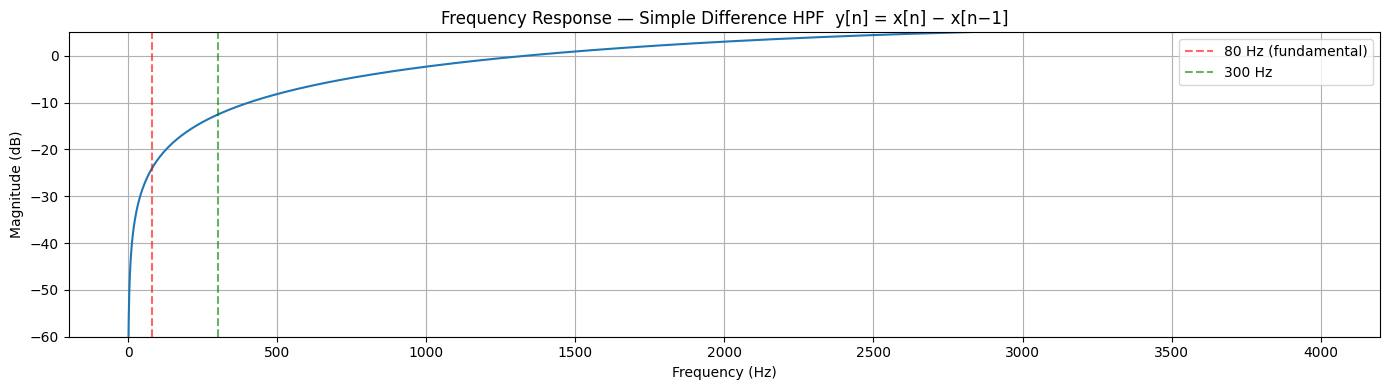

Notice how much the simple filter attenuates frequencies below ~500 Hz!
Attenuation at 80 Hz  : -24.0 dB
Attenuation at 300 Hz : -12.6 dB


In [ ]:
# ---- Apply the simple difference HPF ----
# Coefficients:  b = [1, -1],  a = [1]  (FIR, order 1)
b_simple = np.array([1.0, -1.0])
a_simple = np.array([1.0])

y_simple = signal.lfilter(b_simple, a_simple, x)

# ---- Frequency response of the simple filter ----
w_simple, h_simple = signal.freqz(b_simple, a_simple, worN=4096, fs=fs)

plt.figure(figsize=(14, 4))
plt.plot(w_simple, 20 * np.log10(np.abs(h_simple) + 1e-12))
plt.title('Frequency Response — Simple Difference HPF  y[n] = x[n] − x[n−1]')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.ylim([-60, 5])
plt.axvline(80,  color='r', linestyle='--', alpha=0.6, label='80 Hz (fundamental)')
plt.axvline(300, color='g', linestyle='--', alpha=0.6, label='300 Hz')
plt.legend()
plt.tight_layout()
plt.show()

print('Notice how much the simple filter attenuates frequencies below ~500 Hz!')
print(f'Attenuation at 80 Hz  : {20*np.log10(abs(np.interp(80,  w_simple, np.abs(h_simple)))):.1f} dB')
print(f'Attenuation at 300 Hz : {20*np.log10(abs(np.interp(300, w_simple, np.abs(h_simple)))):.1f} dB')

---
##  Design a Better HPF — FIR (Windowed Sinc Method)

A **Finite Impulse Response (FIR)** filter is designed by specifying:
- `cutoff` — the −3 dB (half-power) frequency
- `numtaps` — the number of filter coefficients (order + 1); more taps → sharper roll-off
- `window` — a window function to reduce spectral leakage (Hamming, Hann, Blackman, etc.)

We use `scipy.signal.firwin` which designs a **low-pass** prototype; to make a high-pass, we pass `pass_zero=False`.

In [15]:
# ---- FIR High-Pass Filter Design ----

cutoff_hz = 40.0    
numtaps   = 101    
window    = 'hamming'

# Design the FIR HPF
b_fir = signal.firwin(
    numtaps,
    cutoff_hz,
    window=window,
    pass_zero=False,   # False => high-pass
    fs=fs
)
a_fir = np.array([1.0])   # FIR: denominator is always 1

# ---- Apply the FIR HPF ----
y_fir = signal.lfilter(b_fir, a_fir, x)

# ---- Frequency response ----
w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=4096, fs=fs)

print(f'FIR filter designed: {numtaps} taps, cut-off = {cutoff_hz} Hz, window = {window}')

FIR filter designed: 101 taps, cut-off = 40.0 Hz, window = hamming


> **Task:** Experiment with `numtaps` (try 51, 101, 201, 401) and `cutoff_hz` (try 20, 40, 80). Observe how the roll-off sharpness changes and how the output signal quality changes.

---
## Design a Better HPF — IIR (Butterworth)

An **Infinite Impulse Response (IIR)** filter achieves sharper roll-off with far fewer coefficients than an FIR filter. The trade-off is that IIR filters introduce **non-linear phase** (frequency-dependent delay).

The **Butterworth** filter is maximally flat in the passband — no ripple.

In [16]:
# ---- IIR Butterworth High-Pass Filter Design ----

order_iir  = 5        
cutoff_iir = 40.0    

# Design using second-order sections (sos) for numerical stability
sos_butter = signal.butter(
    order_iir,
    cutoff_iir,
    btype='high',
    fs=fs,
    output='sos'
)


y_iir = signal.sosfilt(sos_butter, x)

# ---- For plotting: convert SOS to b, a ----
b_iir, a_iir = signal.sos2tf(sos_butter)
w_iir, h_iir = signal.freqz(b_iir, a_iir, worN=4096, fs=fs)

print(f'Butterworth IIR filter designed: order = {order_iir}, cut-off = {cutoff_iir} Hz')

Butterworth IIR filter designed: order = 5, cut-off = 40.0 Hz


> **Task:** Try different `order_iir` values (2, 4, 6, 8). Notice how quickly the roll-off sharpens compared to adding taps to an FIR filter. What trade-offs do you observe?

---
## Step 6: Compare All Three Frequency Responses

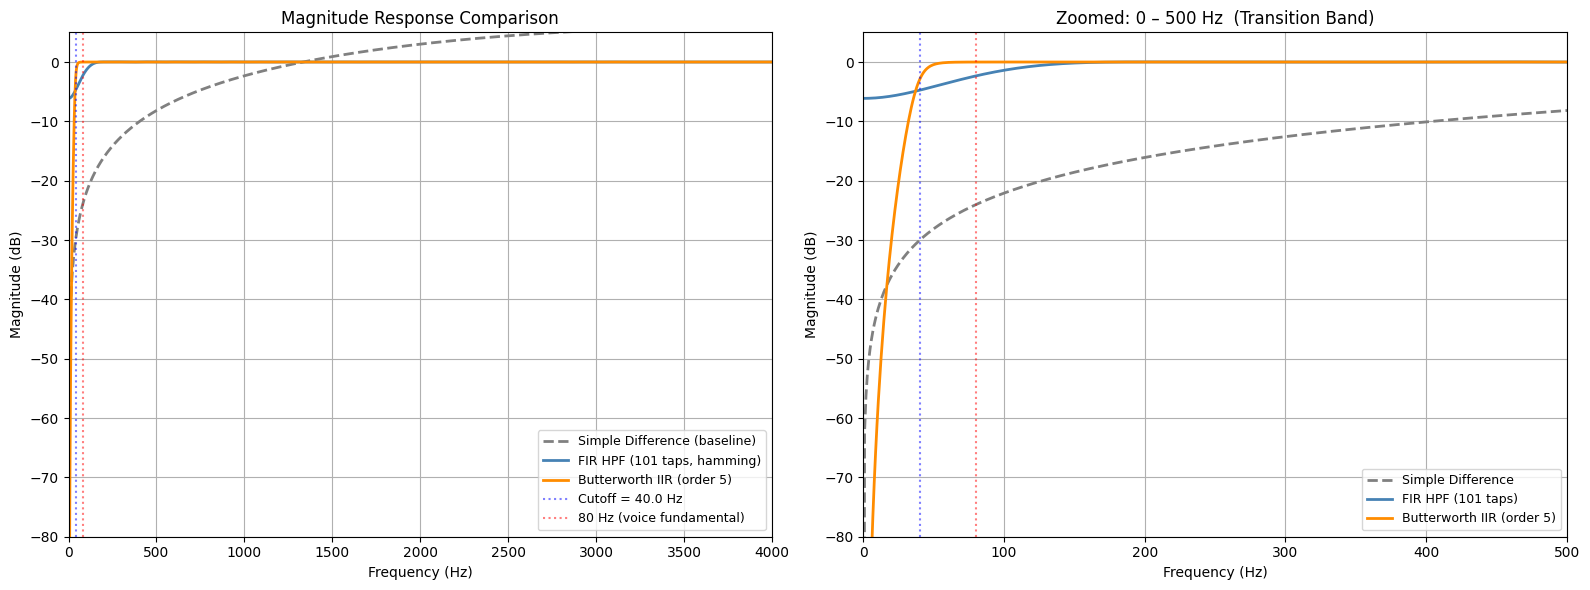

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Magnitude response ----
ax = axes[0]
ax.plot(w_simple, 20*np.log10(np.abs(h_simple) + 1e-12),
        label='Simple Difference (baseline)', color='gray', linewidth=2, linestyle='--')
ax.plot(w_fir,    20*np.log10(np.abs(h_fir)    + 1e-12),
        label=f'FIR HPF ({numtaps} taps, {window})', color='steelblue', linewidth=2)
ax.plot(w_iir,    20*np.log10(np.abs(h_iir)    + 1e-12),
        label=f'Butterworth IIR (order {order_iir})', color='darkorange', linewidth=2)
ax.axvline(cutoff_hz,  color='blue',   linestyle=':', alpha=0.5, label=f'Cutoff = {cutoff_hz} Hz')
ax.axvline(80,          color='red',    linestyle=':', alpha=0.5, label='80 Hz (voice fundamental)')
ax.set_xlim([0, fs/2])
ax.set_ylim([-80, 5])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.set_title('Magnitude Response Comparison')
ax.legend(fontsize=9)

# ---- Zoom into the transition band ----
ax2 = axes[1]
ax2.plot(w_simple, 20*np.log10(np.abs(h_simple) + 1e-12),
         label='Simple Difference', color='gray', linewidth=2, linestyle='--')
ax2.plot(w_fir,    20*np.log10(np.abs(h_fir)    + 1e-12),
         label=f'FIR HPF ({numtaps} taps)', color='steelblue', linewidth=2)
ax2.plot(w_iir,    20*np.log10(np.abs(h_iir)    + 1e-12),
         label=f'Butterworth IIR (order {order_iir})', color='darkorange', linewidth=2)
ax2.axvline(cutoff_hz, color='blue',  linestyle=':', alpha=0.5)
ax2.axvline(80,         color='red',   linestyle=':', alpha=0.5)
ax2.set_xlim([0, 500])    # Zoom into 0–500 Hz (transition + low voice band)
ax2.set_ylim([-80, 5])
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude (dB)')
ax2.set_title('Zoomed: 0 – 500 Hz  (Transition Band)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Step 7: Compare the Output Spectra

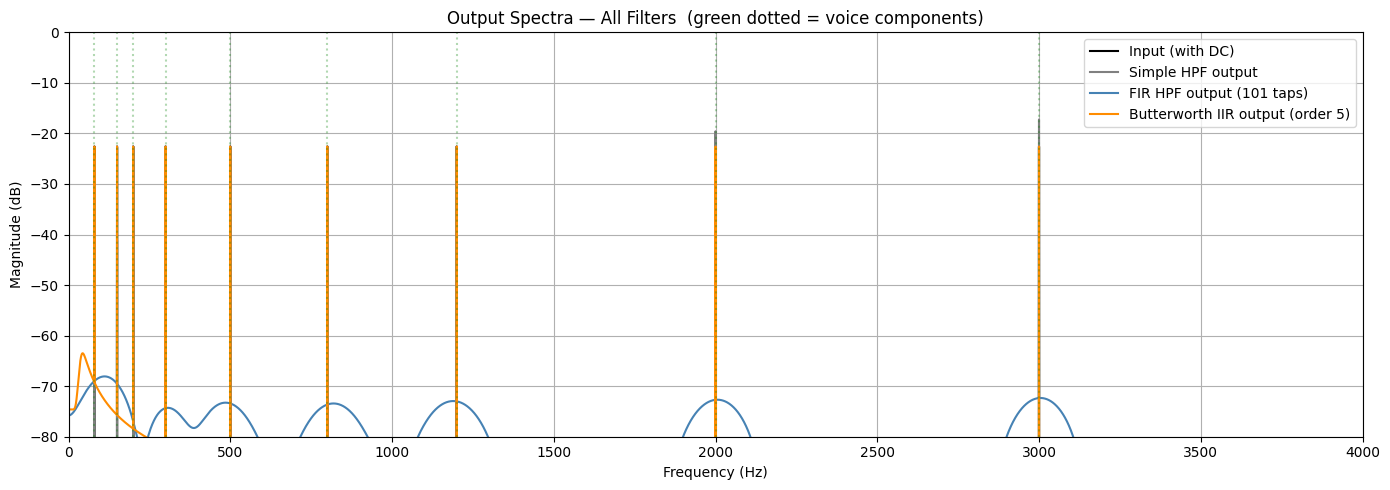

In [7]:
def plot_spectrum(sig, fs, label, ax, color='steelblue'):
    """Plot the one-sided magnitude spectrum of a signal."""
    N = len(sig)
    f = np.fft.rfftfreq(N, d=1/fs)
    S = np.abs(np.fft.rfft(sig)) / N
    ax.plot(f, 20*np.log10(S + 1e-12), label=label, color=color, linewidth=1.5)

fig, ax = plt.subplots(figsize=(14, 5))
plot_spectrum(x,        fs, 'Input (with DC)',              ax, color='black')
plot_spectrum(y_simple, fs, 'Simple HPF output',            ax, color='gray')
plot_spectrum(y_fir,    fs, f'FIR HPF output ({numtaps} taps)', ax, color='steelblue')
plot_spectrum(y_iir,    fs, f'Butterworth IIR output (order {order_iir})', ax, color='darkorange')

# Mark the voice frequency components
for f_c in freqs:
    ax.axvline(f_c, color='green', linestyle=':', alpha=0.3)

ax.set_xlim([0, fs/2])
ax.set_ylim([-80, 0])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.set_title('Output Spectra — All Filters  (green dotted = voice components)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 8: Compare in the Time Domain

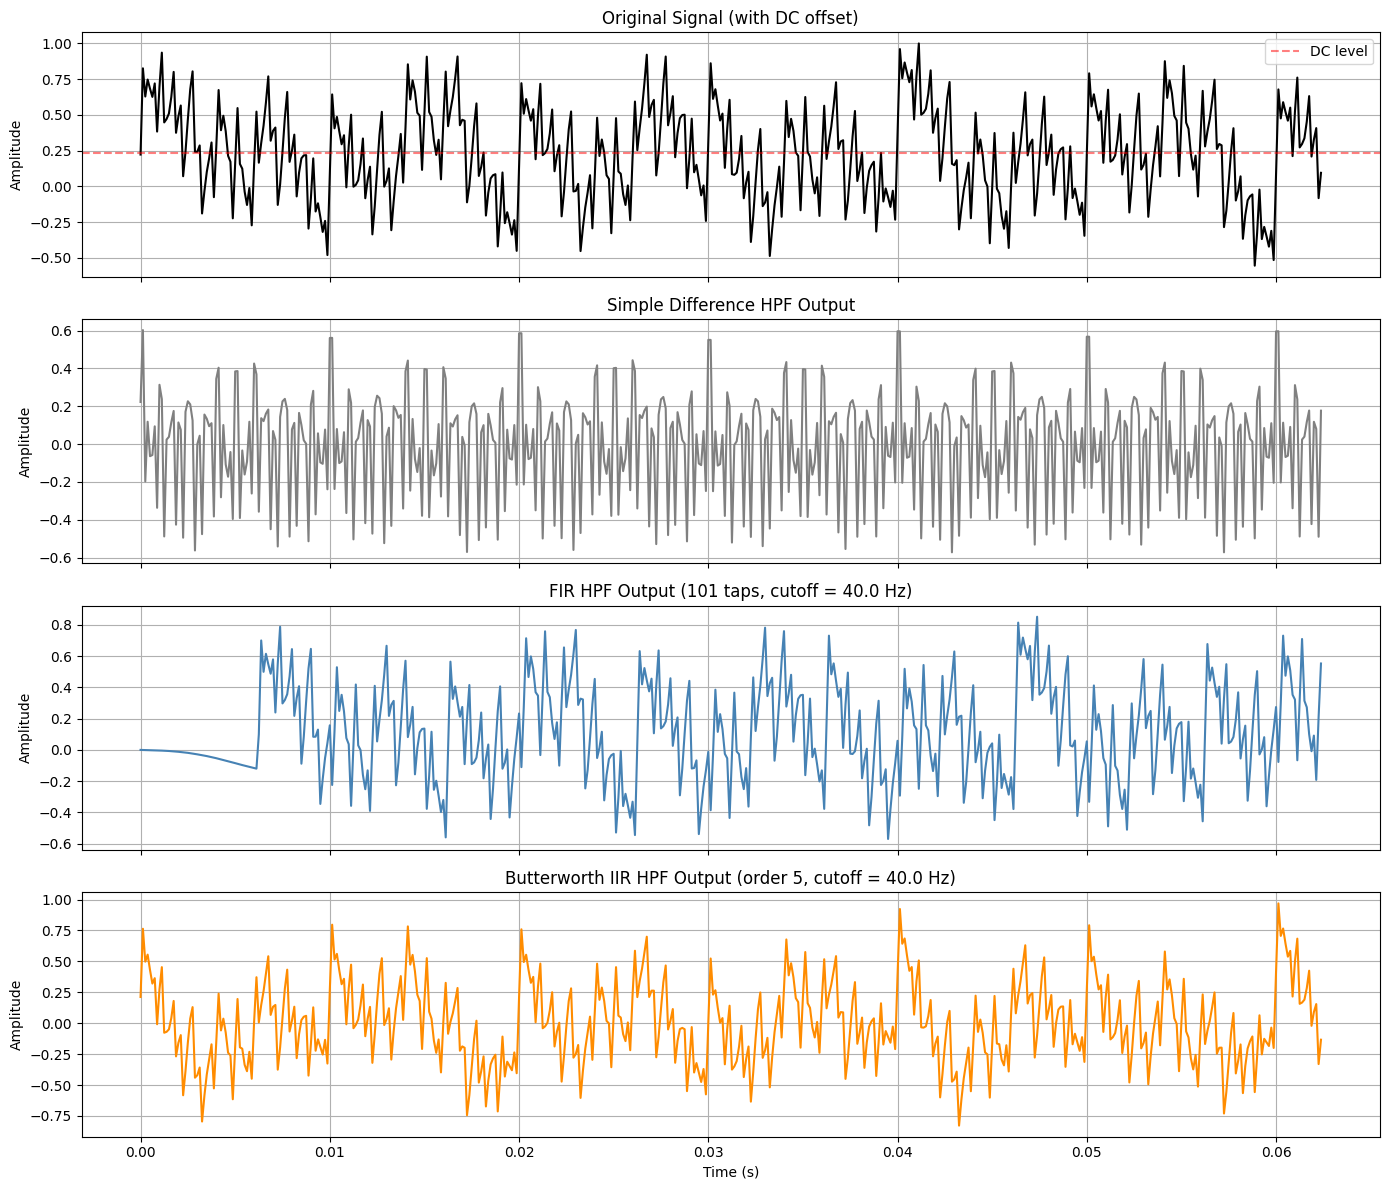

DC level — Original      : 0.2230
DC level — Simple HPF    : -0.0000
DC level — FIR HPF       : 0.1099
DC level — Butterworth   : -0.0002


In [8]:
N_plot = 500   # Show first N_plot samples

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t[:N_plot], x[:N_plot], color='black')
axes[0].set_title('Original Signal (with DC offset)')
axes[0].set_ylabel('Amplitude')
axes[0].axhline(np.mean(x[:N_plot]), color='red', linestyle='--', alpha=0.5, label='DC level')
axes[0].legend()

axes[1].plot(t[:N_plot], y_simple[:N_plot], color='gray')
axes[1].set_title('Simple Difference HPF Output')
axes[1].set_ylabel('Amplitude')

axes[2].plot(t[:N_plot], y_fir[:N_plot], color='steelblue')
axes[2].set_title(f'FIR HPF Output ({numtaps} taps, cutoff = {cutoff_hz} Hz)')
axes[2].set_ylabel('Amplitude')

axes[3].plot(t[:N_plot], y_iir[:N_plot], color='darkorange')
axes[3].set_title(f'Butterworth IIR HPF Output (order {order_iir}, cutoff = {cutoff_iir} Hz)')
axes[3].set_ylabel('Amplitude')
axes[3].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

# Print DC levels after filtering
print(f"DC level — Original      : {np.mean(x):.4f}")
print(f"DC level — Simple HPF    : {np.mean(y_simple):.4f}")
print(f"DC level — FIR HPF       : {np.mean(y_fir):.4f}")
print(f"DC level — Butterworth   : {np.mean(y_iir):.4f}")

---
## Step 9: Listen to the Outputs

If you are working in Jupyter with audio support, play back the signals and hear the difference.

> **Task:** Listen carefully to the simple HPF output vs the FIR/IIR HPF outputs. Do you notice a difference in the bass/low frequencies?

In [9]:
def to_int16(sig):
    """Normalise and convert to 16-bit PCM."""
    sig = sig / (np.max(np.abs(sig)) + 1e-9)
    return (sig * 32767).astype(np.int16)

print('▶  Original signal (with DC):')
ipd.display(ipd.Audio(to_int16(x), rate=fs))

print('▶  Simple difference HPF:')
ipd.display(ipd.Audio(to_int16(y_simple), rate=fs))

print(f'▶  FIR HPF ({numtaps} taps, {cutoff_hz} Hz cutoff):')
ipd.display(ipd.Audio(to_int16(y_fir), rate=fs))

print(f'▶  Butterworth IIR HPF (order {order_iir}, {cutoff_iir} Hz cutoff):')
ipd.display(ipd.Audio(to_int16(y_iir), rate=fs))

▶  Original signal (with DC):


▶  Simple difference HPF:


▶  FIR HPF (101 taps, 40.0 Hz cutoff):


▶  Butterworth IIR HPF (order 5, 40.0 Hz cutoff):


---
## Quantitative Comparison

Let's measure how much each filter preserves the frequencies of interest and suppresses DC.

In [11]:
def mag_at_freq(w, h, target_hz):
    """Return the magnitude (dB) of a filter at a given frequency."""
    mag = np.interp(target_hz, w, np.abs(h))
    return 20 * np.log10(mag + 1e-12)

test_freqs = [0.1, 10, 40, 80, 150, 300, 500, 1000, 3000]

print(f"{'Freq (Hz)':>12}  {'Simple (dB)':>14}  {'FIR (dB)':>12}  {'Butterworth (dB)':>18}")
print('-' * 65)

for f_test in test_freqs:
    s_db  = mag_at_freq(w_simple, h_simple, f_test)
    f_db  = mag_at_freq(w_fir,    h_fir,    f_test)
    i_db  = mag_at_freq(w_iir,    h_iir,    f_test)
    print(f"{f_test:>12.1f}  {s_db:>14.1f}  {f_db:>12.1f}  {i_db:>18.1f}")

print('\nHigher dB = more signal preserved  |  Very negative dB = heavily attenuated (good for DC, bad for voice)')

   Freq (Hz)     Simple (dB)      FIR (dB)    Butterworth (dB)
-----------------------------------------------------------------
         0.1           -82.1          -6.1              -143.0
        10.0           -42.1          -6.0               -60.1
        40.0           -30.1          -4.8                -3.0
        80.0           -24.0          -2.3                -0.0
       150.0           -18.6          -0.2                -0.0
       300.0           -12.6           0.0                -0.0
       500.0            -8.2          -0.0                -0.0
      1000.0            -2.3          -0.0                 0.0
      3000.0             5.3           0.0                 0.0

Higher dB = more signal preserved  |  Very negative dB = heavily attenuated (good for DC, bad for voice)


---
##  Phase Response Comparison

FIR filters designed with symmetric coefficients have **linear phase** (constant group delay — all frequencies delayed equally).  
IIR filters have **non-linear phase**, which can cause audible artefacts if phase is critical.

c:\Users\Brian\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_filter_design.py:703: RuntimeWarning: divide by zero encountered in divide
  gd = np.real(num / den) - a.size + 1
c:\Users\Brian\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_filter_design.py:703: RuntimeWarning: invalid value encountered in divide
  gd = np.real(num / den) - a.size + 1
C:\Users\Brian\AppData\Local\Temp\ipykernel_4088\4038592383.py:21: UserWarning: The group delay is singular at frequencies [0.000], setting to 0
  w_gd, gd = signal.group_delay((b_, a_), w=4096, fs=fs)


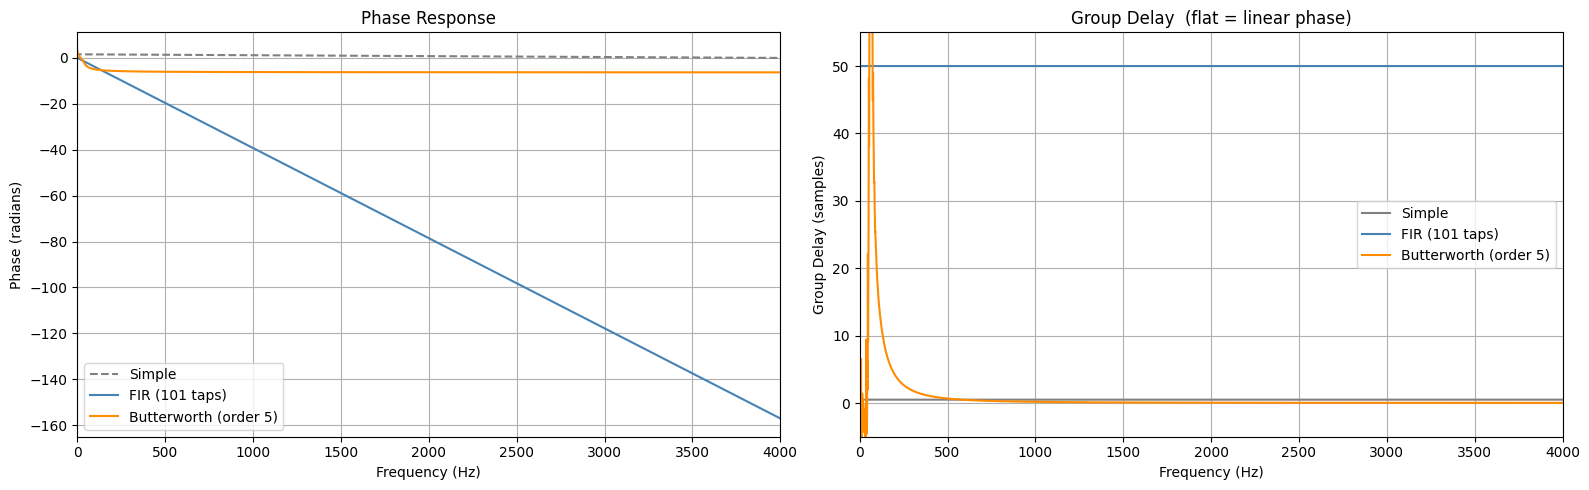

FIR filter group delay (should be flat): (numtaps-1)/2 = 50 samples
Butterworth group delay is frequency-dependent (non-linear phase).


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Phase
ax = axes[0]
ax.plot(w_simple, np.unwrap(np.angle(h_simple)), label='Simple', color='gray', linestyle='--')
ax.plot(w_fir,    np.unwrap(np.angle(h_fir)),    label=f'FIR ({numtaps} taps)', color='steelblue')
ax.plot(w_iir,    np.unwrap(np.angle(h_iir)),    label=f'Butterworth (order {order_iir})', color='darkorange')
ax.set_xlim([0, fs/2])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Phase (radians)')
ax.set_title('Phase Response')
ax.legend()

# Group delay
ax2 = axes[1]
for (b_, a_, label_, color_) in [
    (b_simple, a_simple, 'Simple', 'gray'),
    (b_fir,    a_fir,    f'FIR ({numtaps} taps)', 'steelblue'),
    (b_iir,    a_iir,    f'Butterworth (order {order_iir})', 'darkorange')
]:
    w_gd, gd = signal.group_delay((b_, a_), w=4096, fs=fs)
    ax2.plot(w_gd, gd, label=label_, color=color_)

ax2.set_xlim([0, fs/2])
ax2.set_ylim([-5, max(numtaps//2 + 5, 20)])
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Group Delay (samples)')
ax2.set_title('Group Delay  (flat = linear phase)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'FIR filter group delay (should be flat): (numtaps-1)/2 = {(numtaps-1)//2} samples')
print('Butterworth group delay is frequency-dependent (non-linear phase).')